<a href="https://colab.research.google.com/github/samiralam2k6-code/traffic-website-analysis/blob/main/Traffic_Website_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('/content/data-export (1).csv')

In [3]:
df.head()

,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Unnamed: 10,Unnamed: 11
0,Direct,2024041623,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,NaN,NaN
1,Organic Social,2024041719,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,NaN,NaN
2,Direct,2024041723,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,NaN,NaN
3,Organic Social,2024041718,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,NaN,NaN
4,Organic Social,2024041720,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,NaN,NaN


In [4]:
df=df.drop(columns=['Unnamed: 10','Unnamed: 11' ], axis=1)

In [5]:
df.columns = ['channel group','DateHour','Users','Sessions','Engaged sessions','Average engagement time per session','Engaged sessions per user','Events per session','Engagement rate','Event count']

In [6]:
df.head()

,channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526667,0.607595,4.673333,0.480000,1402
1,Organic Social,2024041719,208,267,132,32.097378,0.634615,4.295880,0.494382,1147
2,Direct,2024041723,188,233,115,39.939914,0.611702,4.587983,0.493562,1069
3,Organic Social,2024041718,187,256,125,32.160156,0.668449,4.078125,0.488281,1044
4,Organic Social,2024041720,175,221,112,46.918552,0.640000,4.529412,0.506787,1001


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   channel group                        3182 non-null   object 
 1   DateHour                             3182 non-null   int64  
 2   Users                                3182 non-null   int64  
 3   Sessions                             3182 non-null   int64  
 4   Engaged sessions                     3182 non-null   int64  
 5   Average engagement time per session  3182 non-null   float64
 6   Engaged sessions per user            3182 non-null   float64
 7   Events per session                   3182 non-null   float64
 8   Engagement rate                      3182 non-null   float64
 9   Event count                          3182 non-null   int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 248.7+ KB


In [8]:
df['DateHour'] = pd.to_datetime(df['DateHour'], format='%Y%m%d%H',errors='coerce')

In [9]:
df.head()

,channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001


In [10]:
df['Hour']=df['DateHour'].dt.hour

In [11]:
df.head()

,channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [12]:
df.describe()

,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


##SESSIONS AND USER OVER TIME


In [13]:
sns.set(style='whitegrid')


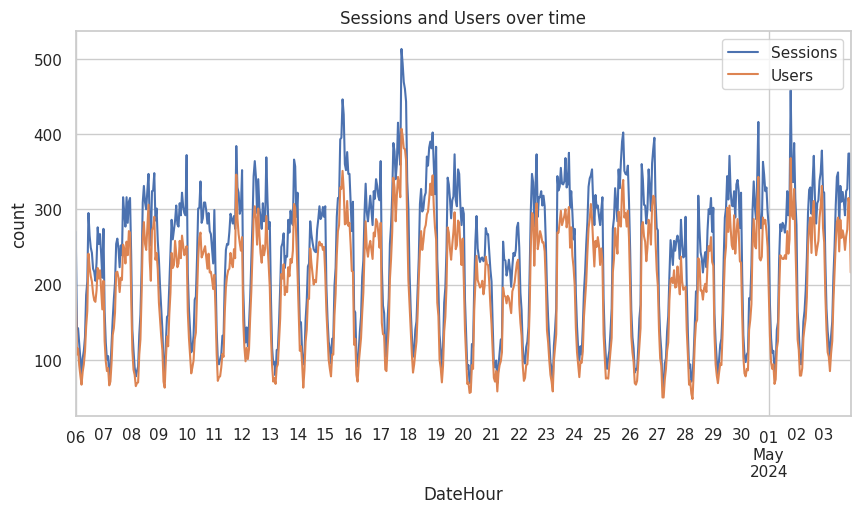

In [14]:
plt.figure(figsize=(10,5))
df.groupby('DateHour')[['Sessions','Users']].sum().plot(ax=plt.gca())
plt.title('Sessions and Users over time')
plt.xlabel('DateHour')
plt.ylabel('count')
plt.show()

### TOTAL USERS BY CHANNEL

/tmp/ipykernel_12328/1817760576.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='channel group', y='Users',estimator=np.sum,palette='viridis')


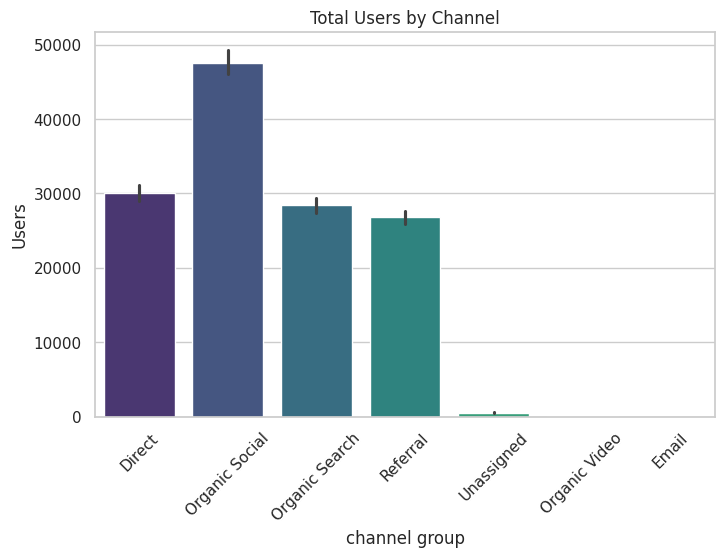

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x='channel group', y='Users',estimator=np.sum,palette='viridis')
plt.title('Total Users by Channel')
plt.xticks(rotation=45)
plt.show()

In [16]:
df.head()

,channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


Average engagement time by channel


/tmp/ipykernel_12328/546004723.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='channel group',y='Average engagement time per session',estimator=np.mean,palette='magma')


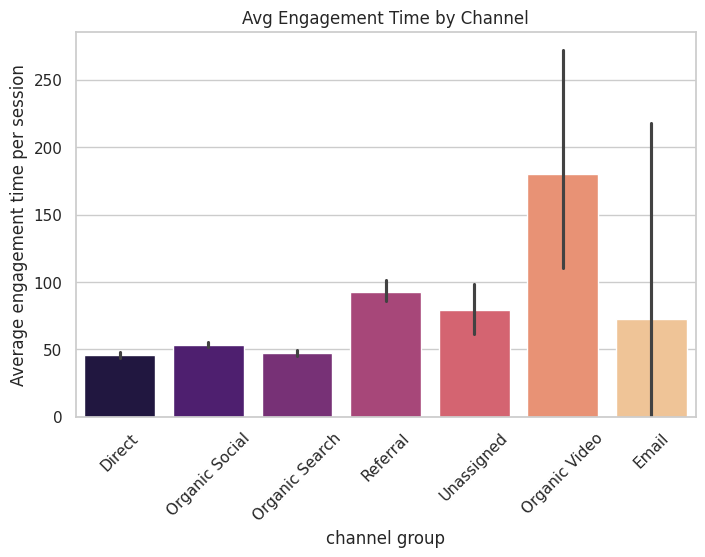

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x='channel group',y='Average engagement time per session',estimator=np.mean,palette='magma')
plt.title('Avg Engagement Time by Channel')
plt.xticks(rotation=45)
plt.show()

In [18]:
df.head()

,channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


# Engagement Rate distribution by channel

/tmp/ipykernel_12328/3678039804.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='channel group',y='Engagement rate',palette='coolwarm')


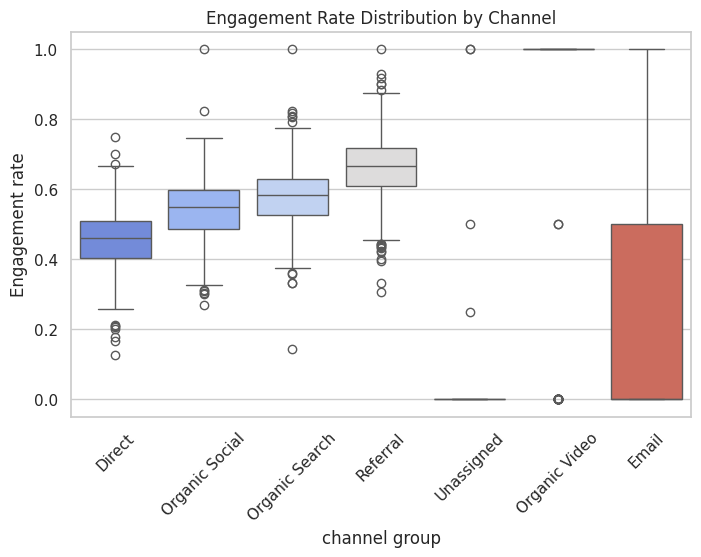

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x='channel group',y='Engagement rate',palette='coolwarm')
plt.title('Engagement Rate Distribution by Channel')
plt.xticks(rotation=45)
plt.show()

#Engaged vs non engaged sessions

In [20]:
 df.head()

,channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


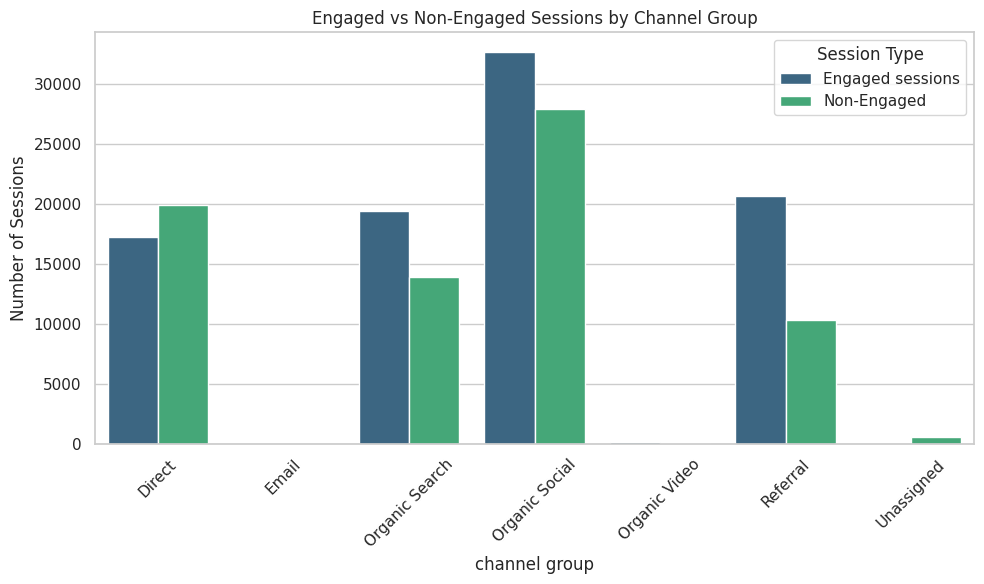

In [31]:
session_df=df.groupby('channel group') [['Sessions','Engaged sessions']].sum().reset_index()
session_df['Non-Engaged']= session_df['Sessions']-session_df['Engaged sessions']
session_df_melted = session_df.melt(id_vars='channel group', value_vars=['Engaged sessions','Non-Engaged'], var_name='Session Type', value_name='Count')
plt.figure(figsize=(10,6))
sns.barplot(data=session_df_melted,x='channel group',y='Count',hue='Session Type', palette='viridis')
plt.title('Engaged vs Non-Engaged Sessions by Channel Group')
plt.ylabel('Number of Sessions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#traffic by hour and channel


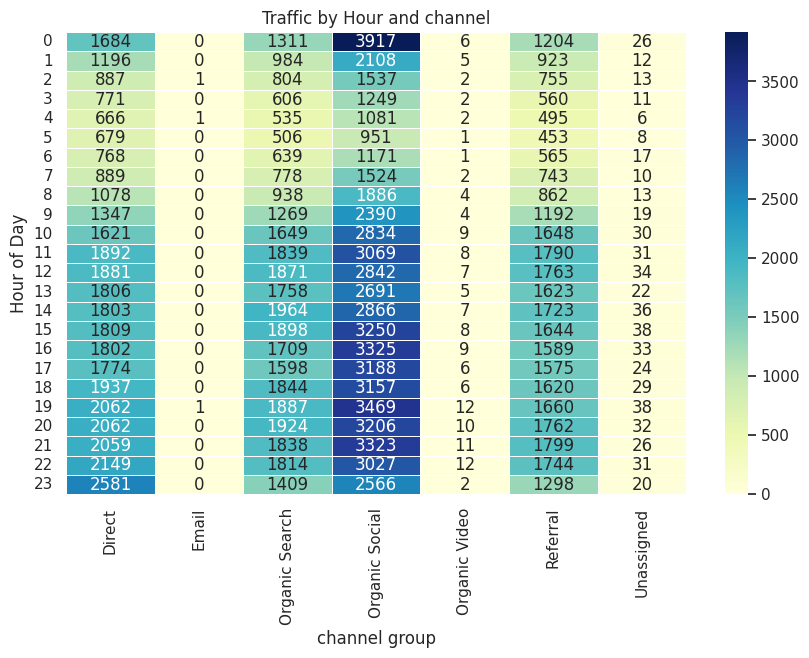

In [33]:
heatmap_data =df.groupby(['Hour','channel group'])['Sessions'].sum().unstack().fillna(0)
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data,cmap='YlGnBu',linewidths=.5,annot=True,fmt='.0f')
plt.title('Traffic by Hour and channel')
plt.xlabel('channel group')
plt.ylabel('Hour of Day')
plt.show()

# engagement rate vs sessions over time

In [34]:
df.head()

,channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


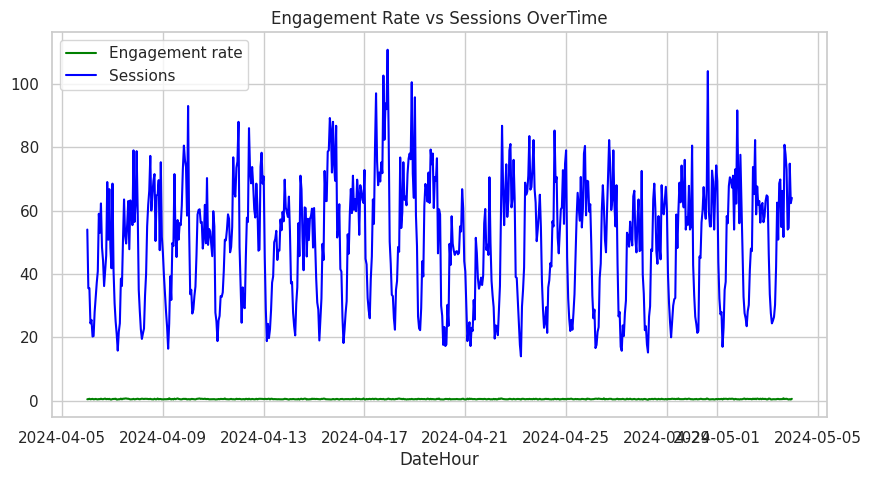

In [38]:
df_plot =df.groupby('DateHour')[['Engagement rate','Sessions']].mean().reset_index()
plt.figure(figsize=(10,5))
plt.plot(df_plot['DateHour'],df_plot['Engagement rate'],label='Engagement rate',color='green')
plt.plot(df_plot['DateHour'],df_plot['Sessions'],label='Sessions',color='blue')
plt.title('Engagement Rate vs Sessions OverTime')
plt.xlabel('DateHour')
plt.legend()
plt.grid(True)
plt.show()